# Imports

In [25]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Path
from pathlib import Path

# HDF5
import h5py

# RegEx
import re

In [26]:
def load_group(name, file):
    return {k: v[()].item() if np.ndim(v[()]) == 0 else v[()] for k, v in file.get(name, {}).items()}

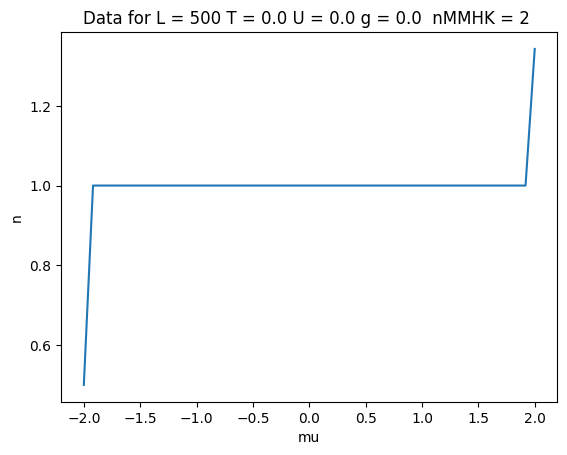

In [27]:
# Get the directory where the script is located
current_dir = Path.cwd()

# Get the output directory
current_out = current_dir / "outputs"

# Iterate through all items in the folder
for file in current_out.iterdir():
    if file.is_file():
        if str(file.suffix) == ".h5":

            # Open the HDF5 file in read mode
            with h5py.File(current_out / file.name, "r") as file:
                
                # Read root-level outputs
                # Using [()] extracts the dataset into a NumPy array
                x_data = file["x_data"][()]
                y_data = file["y_data"][()]
                out1 = file["out1"][()].decode('utf-8')
                
                # Read parameters from the 'params' group into a Python dictionary
                params = load_group("params", file)
                sweep1 = load_group("sweep1", file)
                
                # Title for the plot
                title_str = "Data for " + " ".join(
                    f"{key} = {value}" if key not in (sweep1["param"], "mu", "nTarget") else "" for key, value in params.items()
                )

                # Compare to the theoretical n(mu) curve
                # nn = (2 / np.pi) * np.arccos(-0.5 * x_data)
                # plt.plot(x_data, nn, label=f"Theoretical n(mu)")

                # Make the plot
                plt.plot(x_data, y_data, label=f"nMMHK = {params["nMMHK"]}")
                plt.title(title_str)
                plt.xlabel(sweep1["param"].decode('utf-8'))
                plt.ylabel(out1)
                plt.show()